In [30]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [31]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [32]:
def LLM(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

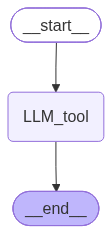

In [33]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph

graph_build = StateGraph(State)

graph_build.add_node("LLM_tool", LLM)

graph_build.add_edge(START, "LLM_tool")
graph_build.add_edge("LLM_tool", END)

graph = graph_build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
res = graph.invoke({"messages": "Add 2 and 8"})

In [35]:
res['messages'][-1].content

'10'

In [36]:
res = graph.invoke({"messages": "Now divide the result by 5"})

In [37]:
res['messages'][-1].content

'I’m not sure which result you’re referring to. Could you let me know the number or calculation you’d like to divide by 5?'

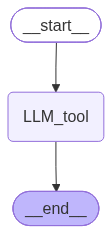

In [39]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

config = {"configurable": {"thread_id": "chat_1"}}

graph_with_memory = graph_build.compile(checkpointer=memory)
display(Image(graph_with_memory.get_graph().draw_mermaid_png()))

In [40]:
res = graph_with_memory.invoke({"messages": "Add 2 and 8"}, config=config)

In [41]:
res['messages'][-1].content

'10'

In [42]:
res = graph_with_memory.invoke({"messages": "Now divide the result by 5"}, config=config)

In [45]:
res['messages'][-1].content

'2'

In [46]:
res['messages'][-1].additional_kwargs['reasoning_content']

'The user: "Now divide the result by 5". They had result 10. 10 divided by 5 = 2. So answer 2.'